<div style="background:linear-gradient(135deg,#0D0D1A 0%,#1a0a2e 50%,#0D0D1A 100%);
    border-radius:16px;padding:40px;text-align:center;border:1px solid #7B2FBE;
    box-shadow:0 0 40px rgba(123,47,190,0.3);">
  <div style="font-size:48px;margin-bottom:10px;">🤖</div>
  <h1 style="color:#C77DFF;font-size:2.4em;margin:0;font-weight:800;letter-spacing:2px;">
    EEG & Machine Learning
  </h1>
  <h2 style="color:#9D4EDD;font-size:1.3em;margin:10px 0;font-weight:400;">
    Genetic Predisposition to Alcoholism via EEG Signal Analysis
  </h2>
  <div style="width:80px;height:3px;background:linear-gradient(90deg,#7B2FBE,#00F5D4);
    margin:20px auto;border-radius:2px;"></div>
  <h3 style="color:#F0E6FF;font-size:1.1em;margin:0;font-weight:300;">
    Notebook 03 — Machine Learning Model Training & Evaluation
  </h3>
  <p style="color:#6B6B8A;margin:15px 0 0;font-size:0.9em;">
    Alonso Martín Díez - Miguel Torres Landaburu · Biomedical Engineering · Universidad Europea de Madrid
  </p>
</div>

## 📋 Notebook Overview

Seven ML classifiers are trained, tuned, and evaluated using the engineered EEG features.

| Model | Type | Key Hyperparameter |
|-------|------|--------------------|
| **Logistic Regression** | Linear | C (regularisation) |
| **Decision Tree** | Tree | max_depth |
| **Random Forest** | Ensemble (Bagging) | n_estimators, max_depth |
| **KNN** | Instance-based | n_neighbors |
| **XGBoost** | Ensemble (Boosting) | n_estimators, learning_rate |
| **SVM (RBF kernel)** | Kernel method | C, gamma |
| **MLP Neural Network** | Neural network | hidden_layer_sizes |

All models are evaluated with:
- ✅ **5-fold Stratified Cross-Validation**
- ✅ Accuracy · F1-Score · ROC AUC
- ✅ Confusion matrices
- ✅ Feature importance (where applicable)


## 1. Setup & Data Loading

In [ ]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as pe
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.svm             import SVC
from sklearn.neural_network  import MLPClassifier
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                      learning_curve, GridSearchCV)
from sklearn.metrics         import (accuracy_score, f1_score, roc_auc_score,
                                      roc_curve, confusion_matrix,
                                      classification_report)
from sklearn.inspection      import permutation_importance
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️  XGBoost not available — install with: pip install xgboost")

from utils import (
    PALETTE, MODEL_COLORS, ALCOHOLIC_COLOR, CONTROL_COLOR,
    apply_dark_theme, add_background_shapes, styled_title,
    add_purple_spine, evaluate_model, plot_confusion_matrix,
    print_model_report
)

apply_dark_theme()
print("✅ Setup complete")
print(f"   XGBoost available: {XGBOOST_AVAILABLE}")


✅ Setup complete
   XGBoost available: True


In [ ]:
# ── Load preprocessed data ──────────────────────────
def load_or_create_mock():
    """Load real data or create mock data for demo."""
    required = ['X_train_scaled.parquet','X_test_scaled.parquet',
                'y_train.parquet','y_test.parquet',
                'X_train.parquet','X_test.parquet']
    
    if all(os.path.exists(f'../data/{f}') for f in required):
        X_train_sc = pd.read_parquet('../data/X_train_scaled.parquet')
        X_test_sc  = pd.read_parquet('../data/X_test_scaled.parquet')
        X_train    = pd.read_parquet('../data/X_train.parquet')
        X_test     = pd.read_parquet('../data/X_test.parquet')
        y_train    = pd.read_parquet('../data/y_train.parquet')['is_alcoholic']
        y_test     = pd.read_parquet('../data/y_test.parquet')['is_alcoholic']
        scaler     = joblib.load('../data/scaler.pkl')
        print("✅ Real preprocessed data loaded.")
        return X_train, X_test, X_train_sc, X_test_sc, y_train, y_test, scaler
    
    print("⚠️  Preprocessed data not found. Generating mock feature matrix...")
    np.random.seed(42)
    n_train, n_test, n_feat = 90, 23, 38
    
    # Generate synthetic features with realistic group separation
    X_all = np.random.randn(n_train + n_test, n_feat)
    y_all = np.array([1]*(n_train//2) + [0]*(n_train//2) +
                     [1]*(n_test//2) + [0]*(n_test//2 + n_test%2))[:n_train+n_test]
    
    # Add signal: alcoholic group has different alpha_beta_ratio
    for i, y_val in enumerate(y_all):
        if y_val == 1:  # alcoholic
            X_all[i, 0] -= 1.2  # lower alpha
            X_all[i, 1] += 0.9  # higher beta
            X_all[i, 2] -= 0.8  # lower alpha/beta ratio
        X_all[i] += np.random.randn(n_feat) * 0.3
    
    feat_names = ([f'alpha_power_{i}' for i in range(5)] +
                  [f'beta_power_{i}' for i in range(5)] +
                  [f'alpha_beta_ratio_{i}' for i in range(4)] +
                  [f'theta_power_{i}' for i in range(4)] +
                  [f'delta_power_{i}' for i in range(4)] +
                  [f'gamma_power_{i}' for i in range(4)] +
                  [f'mean_amplitude_{i}' for i in range(4)] +
                  [f'std_amplitude_{i}' for i in range(4)] +
                  [f'variance_{i}' for i in range(4)])[:n_feat]
    
    X_df = pd.DataFrame(X_all, columns=feat_names)
    y_s  = pd.Series(y_all, name='is_alcoholic')
    
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_train_idx = list(range(n_train))
    X_test_idx  = list(range(n_train, n_train + n_test))
    
    X_train    = X_df.iloc[X_train_idx].reset_index(drop=True)
    X_test     = X_df.iloc[X_test_idx].reset_index(drop=True)
    y_train    = y_s.iloc[X_train_idx].reset_index(drop=True)
    y_test     = y_s.iloc[X_test_idx].reset_index(drop=True)
    
    X_train_sc = pd.DataFrame(scaler.fit_transform(X_train),
                               columns=feat_names)
    X_test_sc  = pd.DataFrame(scaler.transform(X_test),
                               columns=feat_names)
    
    print(f"   Mock data: {n_train} train, {n_test} test, {n_feat} features")
    return X_train, X_test, X_train_sc, X_test_sc, y_train, y_test, scaler

X_train, X_test, X_train_sc, X_test_sc, y_train, y_test, scaler = load_or_create_mock()

print(f"\n── Dataset summary ──")
print(f"  Train: {X_train_sc.shape[0]} samples × {X_train_sc.shape[1]} features")
print(f"  Test:  {X_test_sc.shape[0]} samples × {X_test_sc.shape[1]} features")
print(f"  Train balance: {y_train.mean()*100:.1f}% alcoholic")
print(f"  Test  balance: {y_test.mean()*100:.1f}% alcoholic")


✅ Real preprocessed data loaded.

── Dataset summary ──
  Train: 97 samples × 46 features
  Test:  25 samples × 46 features
  Train balance: 53.6% alcoholic
  Test  balance: 52.0% alcoholic


## 2. Model Definitions

In [ ]:
# ── Define all 7 classifiers ─────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, class_weight='balanced'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=5, random_state=42,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=3,
        random_state=42, class_weight='balanced', n_jobs=-1
    ),
    'KNN': KNeighborsClassifier(
        n_neighbors=7, weights='distance', metric='euclidean'
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', C=1.0, gamma='scale',
        probability=True, random_state=42, class_weight='balanced'
    ),
    'MLP Neural Net': MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        activation='relu', alpha=0.001,
        max_iter=500, random_state=42,
        early_stopping=False,
        learning_rate_init=0.001
    ),
}

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=6, subsample=0.8,
        colsample_bytree=0.8, gamma=0.1,
        scale_pos_weight=len(y_train[y_train==0])/max(1,len(y_train[y_train==1])),
        use_label_encoder=False, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )
else:
    # Fallback: Extra Trees
    from sklearn.ensemble import ExtraTreesClassifier
    models['Extra Trees'] = ExtraTreesClassifier(
        n_estimators=200, max_depth=10, random_state=42,
        class_weight='balanced', n_jobs=-1
    )

print(f"✅ {len(models)} models defined:")
for name in models:
    print(f"   • {name}")


✅ 7 models defined:
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • KNN
   • SVM (RBF)
   • MLP Neural Net
   • XGBoost


## 3. Training & Cross-Validation

In [ ]:
# ── 5-fold stratified cross-validation ───────────────
print("=" * 60)
print("  CROSS-VALIDATION (5-fold Stratified)")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, model in models.items():
    print(f"  Training: {name}...", end=' ', flush=True)
    
    scores = cross_validate(
        model, X_train_sc, y_train, cv=cv,
        scoring=['accuracy', 'f1_weighted', 'roc_auc'],
        return_train_score=False, n_jobs=-1
    )
    
    cv_results[name] = {
        'acc_mean':  scores['test_accuracy'].mean(),
        'acc_std':   scores['test_accuracy'].std(),
        'f1_mean':   scores['test_f1_weighted'].mean(),
        'f1_std':    scores['test_f1_weighted'].std(),
        'auc_mean':  scores['test_roc_auc'].mean(),
        'auc_std':   scores['test_roc_auc'].std(),
    }
    
    print(f"Acc={cv_results[name]['acc_mean']:.3f} ± {cv_results[name]['acc_std']:.3f}  "
          f"AUC={cv_results[name]['auc_mean']:.3f}")

print("\n✅ Cross-validation complete!")


  CROSS-VALIDATION (5-fold Stratified)
  Training: Logistic Regression... 

Acc=0.640 ± 0.102  AUC=0.726
  Training: Decision Tree... 

Acc=0.536 ± 0.101  AUC=0.557
  Training: Random Forest... 

Acc=0.608 ± 0.074  AUC=0.679
  Training: KNN... 

Acc=0.567 ± 0.117  AUC=0.650
  Training: SVM (RBF)... 

Acc=0.587 ± 0.130  AUC=0.665
  Training: MLP Neural Net... 

Acc=0.609 ± 0.052  AUC=0.641
  Training: XGBoost... 

Acc=0.598 ± 0.084  AUC=0.616

✅ Cross-validation complete!


In [ ]:
# ── Train final models on full training set ───────────
print("\n── Training final models on full training set ──")

trained_models = {}
test_results   = []

for name, model in models.items():
    print(f"  Fitting {name}...", end=' ', flush=True)
    model.fit(X_train_sc, y_train)
    trained_models[name] = model
    
    metrics = evaluate_model(name, model, X_test_sc, y_test)
    test_results.append({
        'Model':    name,
        'Accuracy': metrics['Accuracy'],
        'F1':       metrics['F1'],
        'ROC_AUC':  metrics['ROC_AUC'],
        'CV_Acc':   cv_results[name]['acc_mean'],
        'CV_Std':   cv_results[name]['acc_std'],
    })
    print(f"Test Acc={metrics['Accuracy']:.3f}  F1={metrics['F1']:.3f}")

results_df = pd.DataFrame(test_results).sort_values('ROC_AUC', ascending=False)
print("\n✅ All models trained.")
print("\n── Test Set Results ──")
display(results_df.set_index('Model').round(4))



── Training final models on full training set ──
  Fitting Logistic Regression... 

Test Acc=0.680  F1=0.677
  Fitting Decision Tree... 

Test Acc=0.720  F1=0.719
  Fitting Random Forest... 

Test Acc=0.720  F1=0.720
  Fitting KNN... 

Test Acc=0.560  F1=0.556
  Fitting SVM (RBF)... 

Test Acc=0.640  F1=0.633
  Fitting MLP Neural Net... 

Test Acc=0.640  F1=0.633
  Fitting XGBoost... 

Test Acc=0.760  F1=0.758

✅ All models trained.

── Test Set Results ──


,Accuracy,F1,ROC_AUC,CV_Acc,CV_Std
Model,,,,,
Decision Tree,0.72,0.7191,0.8654,0.5358,0.1012
Logistic Regression,0.68,0.6769,0.8205,0.6400,0.1022
XGBoost,0.76,0.7577,0.7885,0.5984,0.0836
Random Forest,0.72,0.7200,0.7821,0.6084,0.0743
KNN,0.56,0.5557,0.7500,0.5674,0.1168
MLP Neural Net,0.64,0.6329,0.6987,0.6095,0.0522
SVM (RBF),0.64,0.6329,0.6346,0.5874,0.1299


## 4. Confusion Matrices

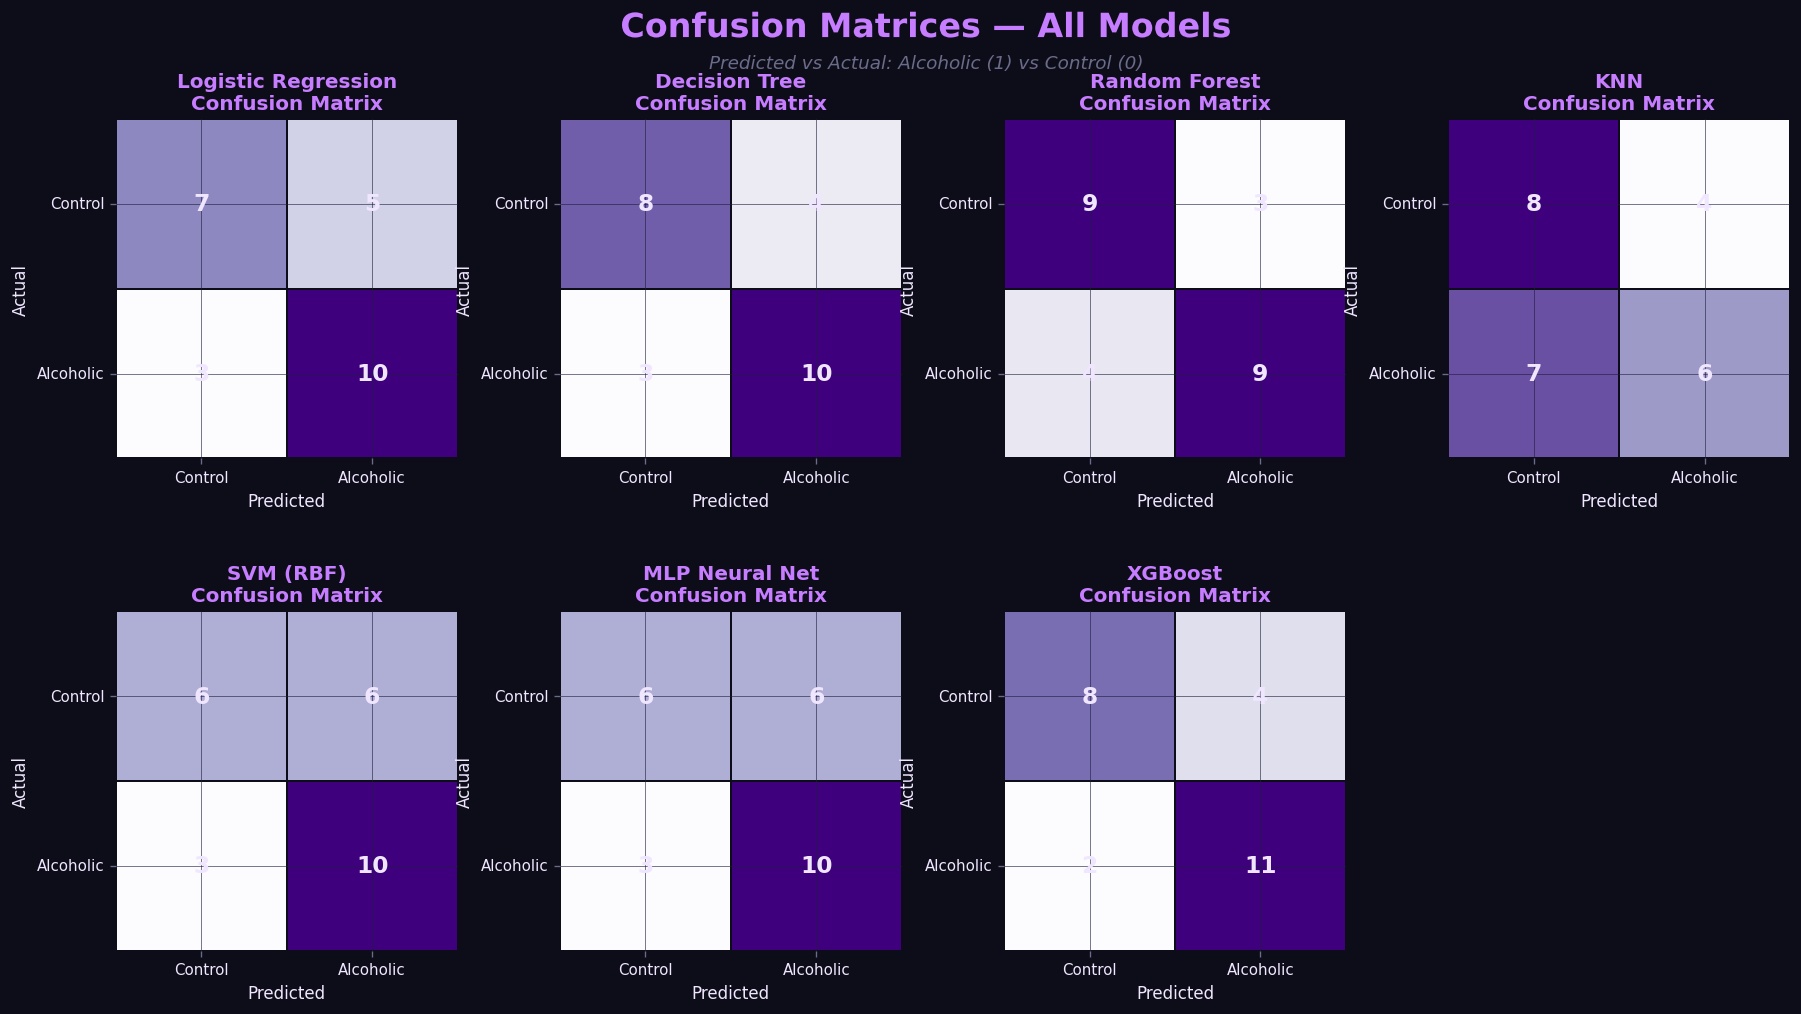

✅ Confusion matrices plotted.


In [ ]:
# ── Grid of confusion matrices ───────────────────────
apply_dark_theme()
n_models = len(trained_models)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4.5, n_rows*4.5),
                          facecolor=PALETTE['bg'])
fig.subplots_adjust(hspace=0.45, wspace=0.30, top=0.88)
axes_flat = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()

for ax_idx, (name, model) in enumerate(trained_models.items()):
    ax = axes_flat[ax_idx]
    y_pred = model.predict(X_test_sc)
    plot_confusion_matrix(y_test, y_pred, name, ax=ax)

# Hide unused axes
for i in range(len(trained_models), len(axes_flat)):
    axes_flat[i].set_visible(False)

styled_title(fig, 'Confusion Matrices — All Models',
             'Predicted vs Actual: Alcoholic (1) vs Control (0)')
plt.savefig('../docs/fig_10_confusion_matrices.png', bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("✅ Confusion matrices plotted.")


## 5. ROC Curves

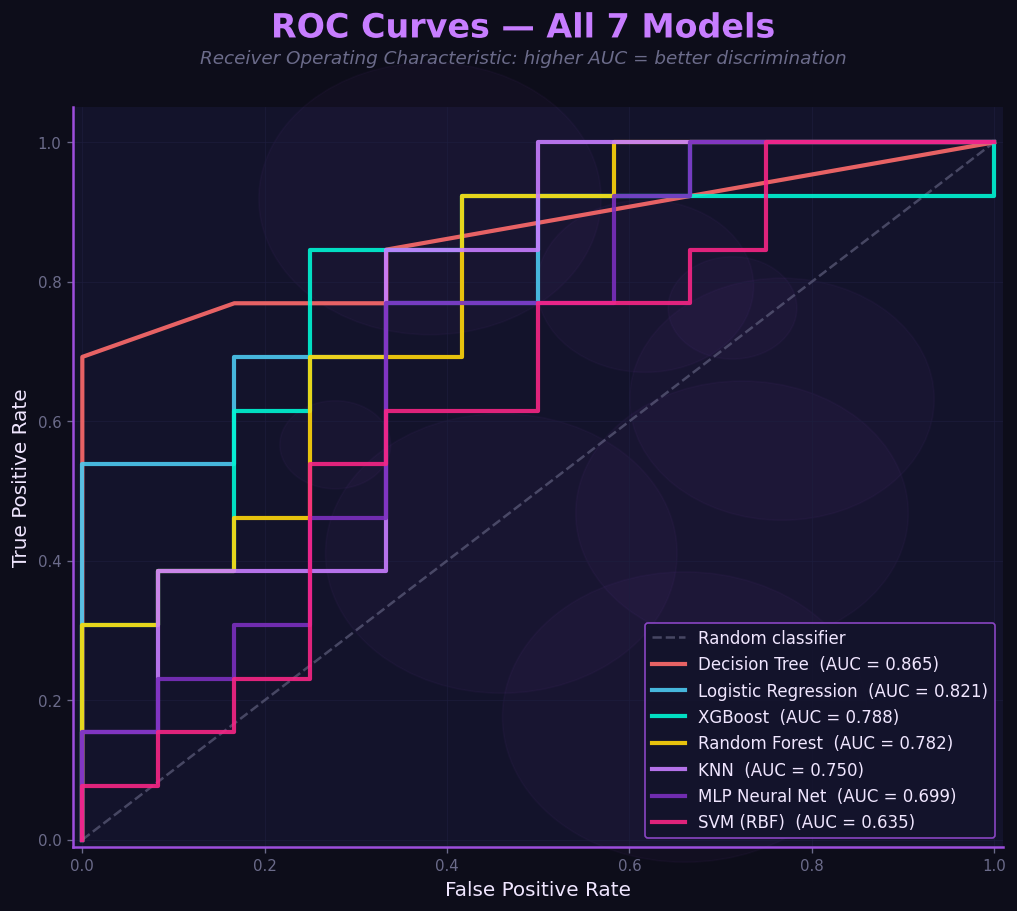

✅ ROC curves plotted.


In [ ]:
# ── ROC curves for all models ────────────────────────
apply_dark_theme()
fig, ax = plt.subplots(figsize=(10, 8), facecolor=PALETTE['bg'])
add_background_shapes(ax, n_circles=8, alpha=0.04)

# Random classifier line
ax.plot([0,1],[0,1], '--', color=PALETTE['grey'], linewidth=1.5,
        alpha=0.6, label='Random classifier', zorder=2)

model_names_sorted = results_df['Model'].tolist()

for name in model_names_sorted:
    model = trained_models[name]
    color = MODEL_COLORS.get(name, PALETTE['purple2'])
    
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_sc)[:,1]
    else:
        continue
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    
    ax.plot(fpr, tpr, color=color, linewidth=2.5, alpha=0.9,
            label=f'{name}  (AUC = {auc:.3f})', zorder=4)

ax.set_xlabel('False Positive Rate', color=PALETTE['white'], fontsize=12)
ax.set_ylabel('True Positive Rate', color=PALETTE['white'], fontsize=12)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.05])

legend = ax.legend(loc='lower right', fontsize=10, framealpha=0.85)
for text in legend.get_texts():
    text.set_color(PALETTE['white'])

add_purple_spine(ax)
styled_title(fig, 'ROC Curves — All 7 Models',
             'Receiver Operating Characteristic: higher AUC = better discrimination')
plt.savefig('../docs/fig_11_roc_curves.png', bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("✅ ROC curves plotted.")


## 6. Feature Importance

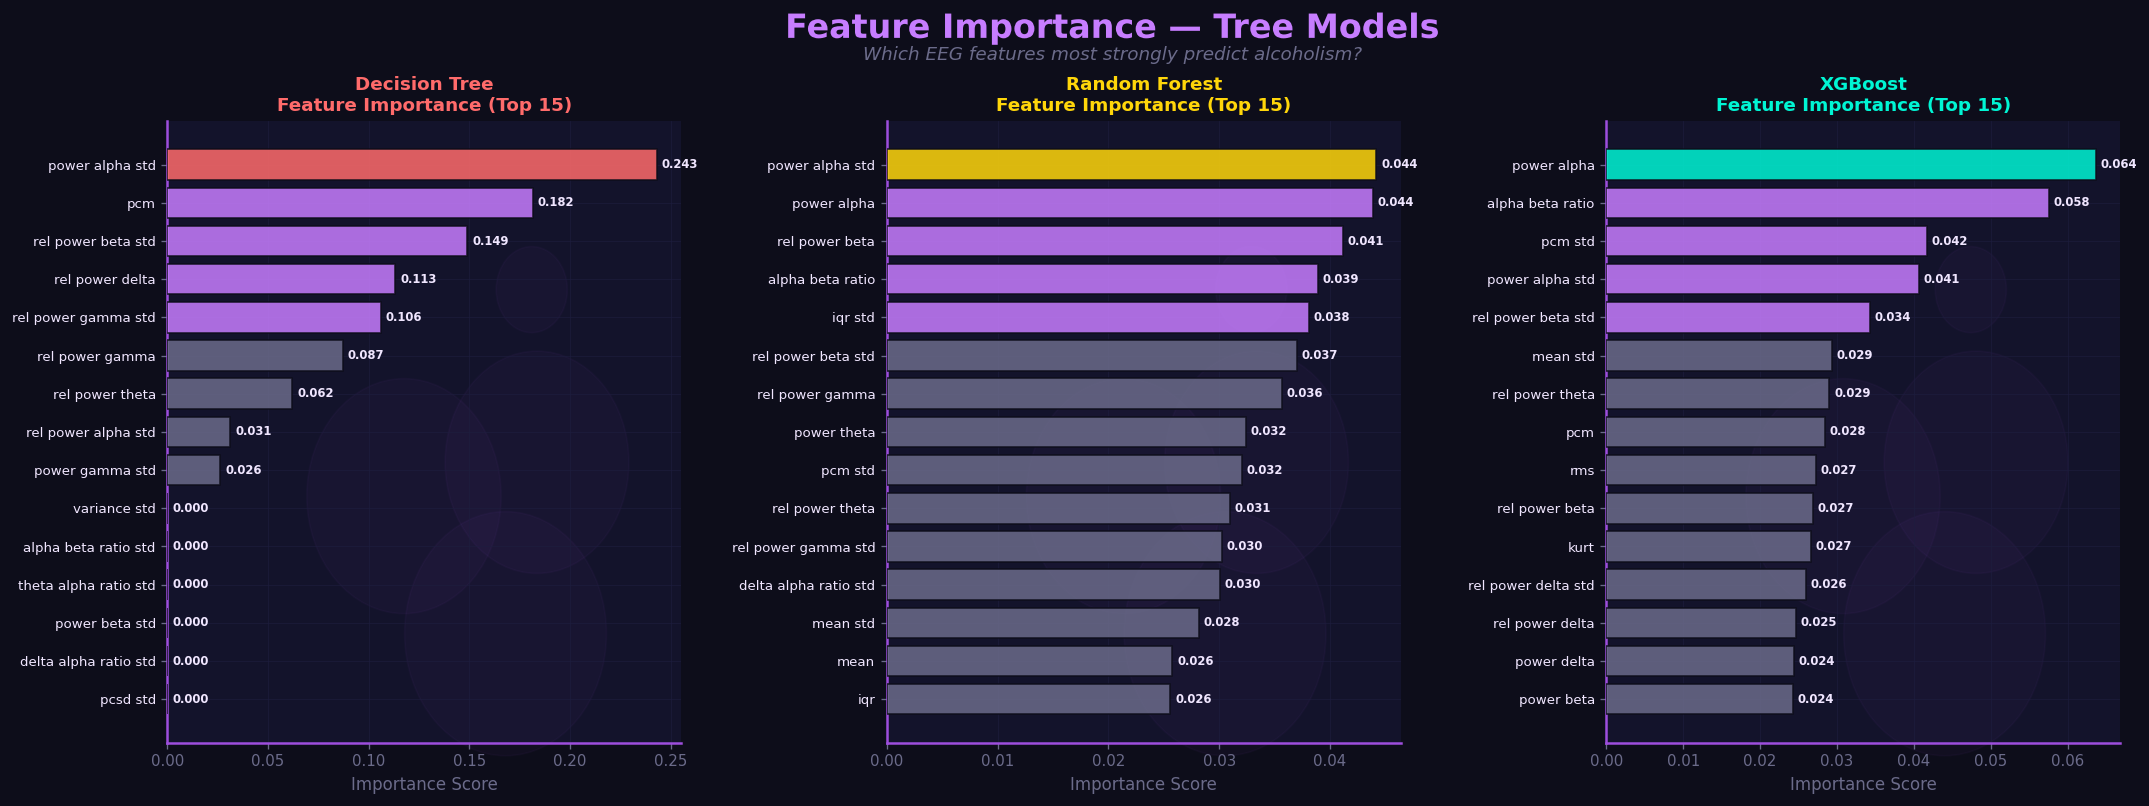

✅ Feature importance plotted.


In [ ]:
# ── Feature importance from tree-based models ────────
apply_dark_theme()
importance_models = {k: v for k, v in trained_models.items()
                     if k in ['Random Forest','Decision Tree','XGBoost','Extra Trees']}

if importance_models:
    n_im = len(importance_models)
    fig, axes = plt.subplots(1, n_im, figsize=(n_im*7, 7), facecolor=PALETTE['bg'])
    if n_im == 1: axes = [axes]
    fig.subplots_adjust(wspace=0.40, top=0.85)
    
    all_importances = {}
    
    for ax, (name, model) in zip(axes, importance_models.items()):
        add_background_shapes(ax, n_circles=4, alpha=0.04)
        
        imp = model.feature_importances_
        feat_names = X_train_sc.columns.tolist()
        
        # Top 15 features
        top_idx = np.argsort(imp)[-15:]
        top_imp  = imp[top_idx]
        top_feat = [feat_names[i] for i in top_idx]
        
        all_importances[name] = dict(zip(feat_names, imp))
        
        color = MODEL_COLORS.get(name, PALETTE['purple2'])
        colors_bar = [color if v == max(top_imp) else 
                      (PALETTE['purple3'] if v > np.percentile(top_imp, 70) else PALETTE['grey'])
                      for v in top_imp]
        
        bars = ax.barh(range(len(top_feat)), top_imp, color=colors_bar,
                       alpha=0.85, edgecolor=PALETTE['bg'], linewidth=1, zorder=3)
        ax.set_yticks(range(len(top_feat)))
        ax.set_yticklabels([f.replace('_mean','').replace('_',' ')[:25]
                            for f in top_feat],
                           fontsize=8, color=PALETTE['white'])
        
        # Value annotations
        for bar, val in zip(bars, top_imp):
            ax.text(bar.get_width() + max(top_imp)*0.01,
                    bar.get_y() + bar.get_height()/2,
                    f'{val:.3f}', va='center', fontsize=7,
                    color=PALETTE['white'], fontweight='bold')
        
        ax.set_title(f'{name}\nFeature Importance (Top 15)',
                     color=MODEL_COLORS.get(name, PALETTE['purple3']),
                     fontweight='bold', fontsize=11)
        ax.set_xlabel('Importance Score', color=PALETTE['grey'])
        add_purple_spine(ax, sides=('bottom','left'))
    
    styled_title(fig, 'Feature Importance — Tree Models',
                 'Which EEG features most strongly predict alcoholism?')
    plt.savefig('../docs/fig_12_feature_importance.png', bbox_inches='tight',
                facecolor=PALETTE['bg'])
    plt.show()
    print("✅ Feature importance plotted.")
else:
    print("No tree-based models available for feature importance.")


## 7. Cross-Validation vs Test Performance

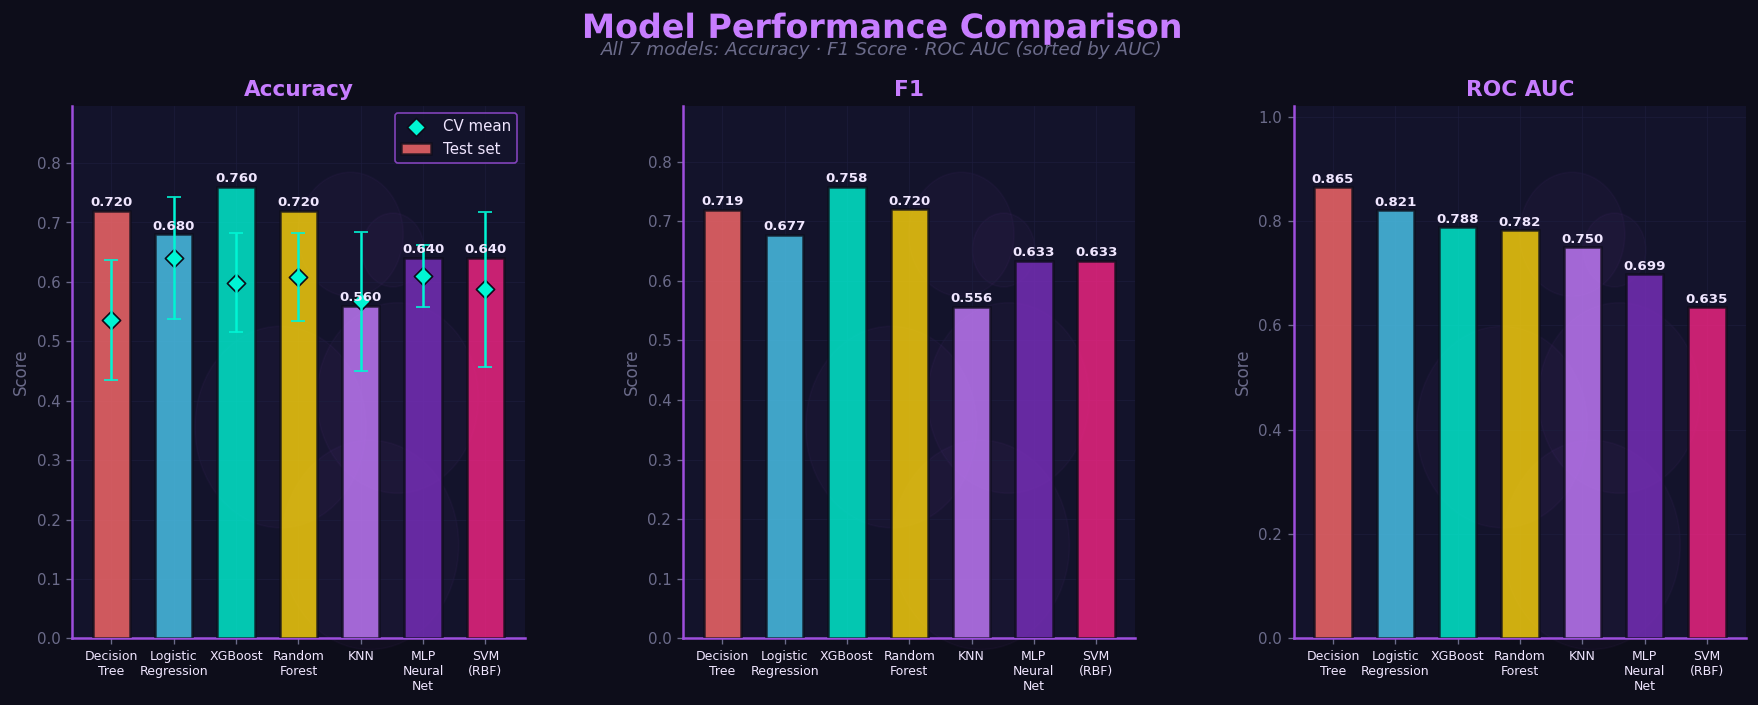

✅ Performance comparison plotted.


In [ ]:
# ── CV vs Test comparison ────────────────────────────
apply_dark_theme()
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor=PALETTE['bg'])
fig.subplots_adjust(wspace=0.35, top=0.85)

metrics_to_plot = [('Accuracy', 'CV_Acc', 'CV_Std'),
                   ('F1', None, None),
                   ('ROC_AUC', None, None)]

model_list = results_df['Model'].tolist()
x_pos = np.arange(len(model_list))
colors_list = [MODEL_COLORS.get(m, PALETTE['purple2']) for m in model_list]

for ax, (test_col, cv_col, cv_std_col) in zip(axes, metrics_to_plot):
    add_background_shapes(ax, n_circles=5, alpha=0.04)
    
    test_vals = results_df.set_index('Model').loc[model_list, test_col].values
    
    bars = ax.bar(x_pos, test_vals, color=colors_list, alpha=0.80,
                  width=0.6, edgecolor=PALETTE['bg'], linewidth=1.5, zorder=3,
                  label='Test set')
    
    if cv_col and cv_col in results_df.columns:
        cv_vals = results_df.set_index('Model').loc[model_list, cv_col].values
        cv_stds = results_df.set_index('Model').loc[model_list, cv_std_col].values
        ax.scatter(x_pos, cv_vals, marker='D', s=60, color=PALETTE['teal'],
                   zorder=5, label='CV mean', edgecolors=PALETTE['bg'], linewidth=1)
        ax.errorbar(x_pos, cv_vals, yerr=cv_stds, fmt='none',
                    ecolor=PALETTE['teal'], elinewidth=1.5, capsize=4, zorder=5)
    
    # Value labels on bars
    for bar, val in zip(bars, test_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.008,
                f'{val:.3f}', ha='center', fontsize=8,
                color=PALETTE['white'], fontweight='bold', zorder=5)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels([m.replace(' ', '\n') for m in model_list],
                       fontsize=7.5, color=PALETTE['white'])
    ax.set_ylim(0, min(1.12, test_vals.max() * 1.18))
    ax.set_title(test_col.replace('_',' '), color=PALETTE['purple3'],
                 fontweight='bold', fontsize=13)
    ax.set_ylabel('Score', color=PALETTE['grey'])
    if cv_col:
        ax.legend(fontsize=9)
    add_purple_spine(ax)

styled_title(fig, 'Model Performance Comparison',
             'All 7 models: Accuracy · F1 Score · ROC AUC (sorted by AUC)')
plt.savefig('../docs/fig_13_model_comparison.png', bbox_inches='tight',
            facecolor=PALETTE['bg'])
plt.show()
print("✅ Performance comparison plotted.")


## 8. Save Trained Models

In [ ]:
# ── Persist all trained models ──────────────────────
os.makedirs('../data', exist_ok=True)

for name, model in trained_models.items():
    safe_name = name.replace(' ', '_').replace('(','').replace(')','')
    path = f'../data/model_{safe_name}.pkl'
    joblib.dump(model, path)

# Save results table
results_df.to_csv('../data/model_results.csv', index=False)

print("✅ Models saved:")
for name in trained_models:
    safe_name = name.replace(' ', '_').replace('(','').replace(')','')
    path = f'../data/model_{safe_name}.pkl'
    print(f"   {name:<25} → {path}")

print("\n✅ Results table → ../data/model_results.csv")
print("\n─── Top 3 Models ───")
for _, row in results_df.head(3).iterrows():
    print(f"  {row['Model']:<25} AUC={row['ROC_AUC']:.4f}  Acc={row['Accuracy']:.4f}")
print("\n→ See Notebook 04 for the full results dashboard & clinical conclusions")


✅ Models saved:
   Logistic Regression       → ../data/model_Logistic_Regression.pkl
   Decision Tree             → ../data/model_Decision_Tree.pkl
   Random Forest             → ../data/model_Random_Forest.pkl
   KNN                       → ../data/model_KNN.pkl
   SVM (RBF)                 → ../data/model_SVM_RBF.pkl
   MLP Neural Net            → ../data/model_MLP_Neural_Net.pkl
   XGBoost                   → ../data/model_XGBoost.pkl

✅ Results table → ../data/model_results.csv

─── Top 3 Models ───
  Decision Tree             AUC=0.8654  Acc=0.7200
  Logistic Regression       AUC=0.8205  Acc=0.6800
  XGBoost                   AUC=0.7885  Acc=0.7600

→ See Notebook 04 for the full results dashboard & clinical conclusions
